# Notebook 2: PPI Prediction

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

In [60]:
# load outputs from Notebook 1
data = pd.read_csv('outputs/data_imputed.tsv', sep='\t', index_col=0)

with open('outputs/gold_pairs.pkl', 'rb') as f:
    gold_pairs = pickle.load(f)

In [61]:
data.head()

,Patient_1,Patient_2,Patient_3,Patient_4,Patient_5,Patient_6,Patient_7,Patient_8,Patient_9,Patient_10,...,Patient_109,Patient_110,Patient_111,Patient_112,Patient_113,Patient_114,Patient_115,Patient_116,Patient_117,Patient_118
A1BG,-0.248427,0.342380,-0.422836,0.523159,0.838483,0.104756,0.152693,-0.307978,0.015145,-0.250013,...,0.604403,0.120395,0.276506,-0.224080,-0.193982,0.258954,0.061537,0.370149,0.490885,0.185676
A2M,-1.204522,-0.329580,-0.680533,0.075529,1.109671,-0.513389,-0.064456,-1.147968,-0.035746,-1.178612,...,0.886675,-0.689876,0.328976,-0.685488,-1.077732,-0.347891,-0.466748,1.296028,1.295298,-0.273764
AAAS,0.250455,-0.042588,0.123734,0.262234,0.166103,0.104671,0.084311,0.032663,0.266344,0.269713,...,0.105247,-0.110949,-0.076646,-0.017859,0.104261,0.121138,0.102050,0.356460,-0.087324,0.542225
AACS,0.332777,0.801353,0.620108,-0.028909,0.205515,-0.288173,0.173700,-0.019604,-0.300753,-0.527521,...,-0.088388,-0.299584,-0.115912,-0.214156,0.067791,0.087183,0.855150,0.455009,0.241351,0.095773
AADAT,-0.865041,-1.460905,-1.188897,-1.290277,-1.554209,-1.602774,-1.425772,-1.342417,-1.583921,-0.082984,...,0.336694,-0.496572,-0.521811,-0.267679,1.717657,0.187466,-0.054714,-0.141242,-0.361436,-0.205090


In [62]:
print(f'Expression data: {data.shape[0]:,} proteins × {data.shape[1]} patients')
print(f'CORUM gold pairs:{len(gold_pairs):,}')

Expression data: 10,164 proteins × 118 patients
CORUM gold pairs:39,430


## Step 1: Compute Correlations - Spearman and Pearson

In [63]:
spearman_corr = data.T.corr(method='spearman')

In [64]:
spearman_corr.shape

(10164, 10164)

In [65]:
pearson_corr = data.T.corr(method='pearson')

## Step 2: Evaluate Against CORUM

In [66]:
# building a lookup for protein name
proteins = list(data.index)
gene_to_idx = {gene: i for i, gene in enumerate(proteins)}

# extract matrices as numpy arrays for fast index based lookup
spearman_mat = spearman_corr.values
pearson_mat  = pearson_corr.values

# get scores for all CORUM pairs
corum_spearman = []
corum_pearson  = []

for (a, b) in gold_pairs:
    if a in gene_to_idx and b in gene_to_idx:
        i = gene_to_idx[a]
        j = gene_to_idx[b]
        corum_spearman.append(spearman_mat[i, j])
        corum_pearson.append(pearson_mat[i, j])

corum_spearman = np.array(corum_spearman)
corum_pearson  = np.array(corum_pearson)

print(f'CORUM pairs with scores: {len(corum_spearman):,}')
print(f'Mean Spearman rho for CORUM pairs: {corum_spearman.mean():.3f}')

CORUM pairs with scores: 39,430
Mean Spearman rho for CORUM pairs: 0.388


In [67]:
# sample 5,00,000 random (negative) pairs
# we exclude CORUM pairs and self pairs which are at the diagonal
np.random.seed(42)

n = len(proteins)
corum_set = set(gold_pairs)

neg_spearman = []
neg_pearson  = []

while len(neg_spearman) < 500000:
    i = np.random.randint(0, n)
    j = np.random.randint(0, n)
    # skip self pairs
    if i == j:
        continue
    pair = tuple(sorted([proteins[i], proteins[j]]))
     # check corum pairs
    if pair not in corum_set: 
        neg_spearman.append(spearman_mat[i, j])
        neg_pearson.append(pearson_mat[i, j])

neg_spearman = np.array(neg_spearman)
neg_pearson  = np.array(neg_pearson)

print(f'Random (negative) pairs sampled: {len(neg_spearman):,}')
print(f'Mean Spearman rho for random pairs: {neg_spearman.mean():.3f}')

Random (negative) pairs sampled: 500,000
Mean Spearman rho for random pairs: 0.001


In [68]:
# Compute AUROC and AUPRC
# y_true: 1 = CORUM pair (positive), 0 = random pair (negative)
y_true    = np.concatenate([np.ones(len(corum_spearman)), np.zeros(len(neg_spearman))])
scores_sp = np.concatenate([corum_spearman, neg_spearman])
scores_pe = np.concatenate([corum_pearson,  neg_pearson])

auroc_sp = roc_auc_score(y_true, scores_sp)
auroc_pe = roc_auc_score(y_true, scores_pe)
auprc_sp = average_precision_score(y_true, scores_sp)
auprc_pe = average_precision_score(y_true, scores_pe)
baseline  = y_true.mean()

In [69]:
print("Evaluation Results vs CORUM Gold Standard")
print("Method\t\t\tAUROC\tAUPRC\tLift")
print("-" * 45)

print(f"Spearman rho\t\t{auroc_sp:.3f}\t{auprc_sp:.3f}\t{auprc_sp/baseline:.1f}x")
print(f"Pearson r\t\t{auroc_pe:.3f}\t{auprc_pe:.3f}\t{auprc_pe/baseline:.1f}x")
print(f"Random baseline\t\t0.500\t{baseline:.3f}\t1.0x\n")

Evaluation Results vs CORUM Gold Standard
Method			AUROC	AUPRC	Lift
---------------------------------------------
Spearman rho		0.848	0.567	7.8x
Pearson r		0.846	0.559	7.6x
Random baseline		0.500	0.073	1.0x



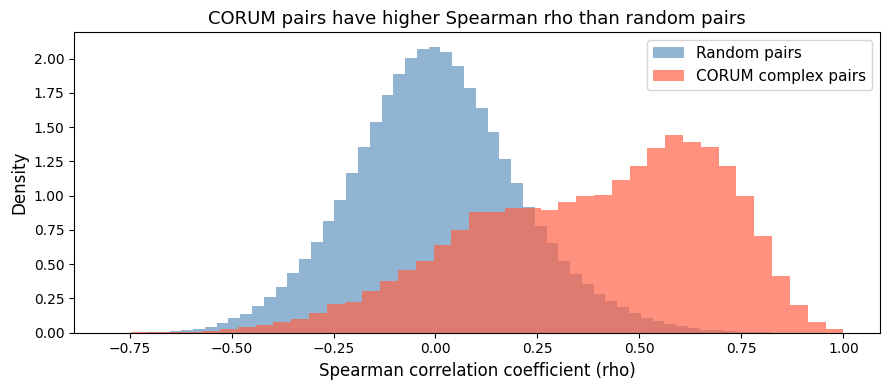

In [70]:
# plot 1: score distributions
plt.figure(figsize=(9, 4))
plt.hist(neg_spearman,  bins=60, density=True, alpha=0.6, color='steelblue', label='Random pairs')
plt.hist(corum_spearman, bins=40, density=True, alpha=0.7, color='tomato',    label='CORUM complex pairs')
plt.xlabel('Spearman correlation coefficient (rho)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('CORUM pairs have higher Spearman rho than random pairs', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('outputs/figures/nb2v2_score_separation.png', dpi=150)
plt.show()

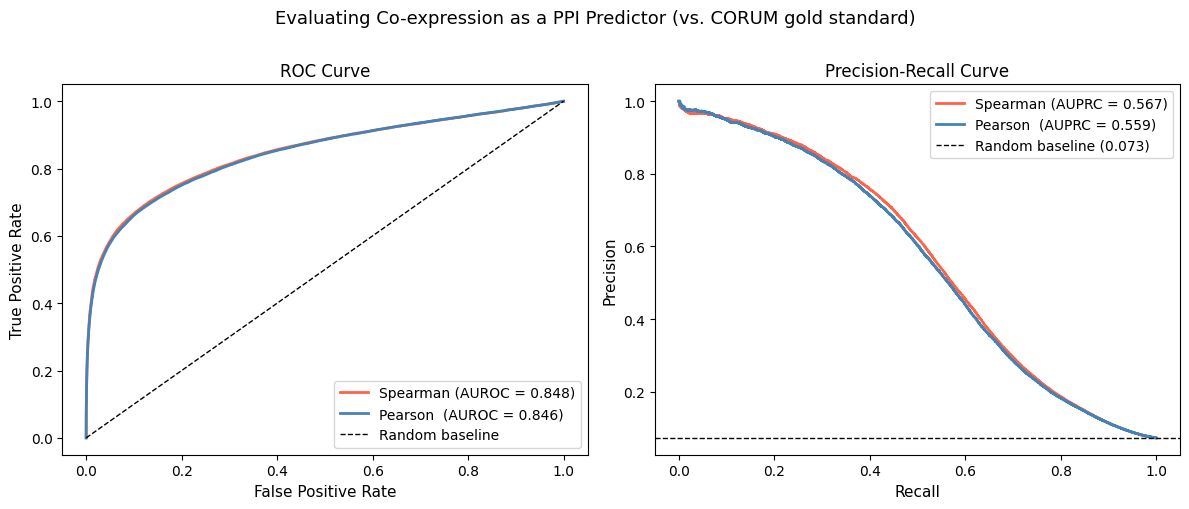

In [71]:
# Plot 2: ROC and Precision-Recall curves for both methods
prec_sp, rec_sp, _ = precision_recall_curve(y_true, scores_sp)
prec_pe, rec_pe, _ = precision_recall_curve(y_true, scores_pe)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
fpr_sp, tpr_sp, _ = roc_curve(y_true, scores_sp)
fpr_pe, tpr_pe, _ = roc_curve(y_true, scores_pe)
ax = axes[0]
ax.plot(fpr_sp, tpr_sp, color='tomato',    lw=2, label=f'Spearman (AUROC = {auroc_sp:.3f})')
ax.plot(fpr_pe, tpr_pe, color='steelblue', lw=2, label=f'Pearson  (AUROC = {auroc_pe:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12)
ax.legend(fontsize=10)

# Precision-Recall curve
ax = axes[1]
ax.plot(rec_sp, prec_sp, color='tomato',    lw=2, label=f'Spearman (AUPRC = {auprc_sp:.3f})')
ax.plot(rec_pe, prec_pe, color='steelblue', lw=2, label=f'Pearson  (AUPRC = {auprc_pe:.3f})')
ax.axhline(baseline, color='black', linestyle='--', lw=1, label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12)
ax.legend(fontsize=10)

plt.suptitle('Evaluating Co-expression as a PPI Predictor (vs. CORUM gold standard)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/nb2v2_eval_curves.png', dpi=150)
plt.show()

In [72]:
# thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.80]
# results = []

# print('running threshold sensitivity analysis\n')
# for THRESHOLD in thresholds:
#     n_edges = 0
#     n_corum = 0

#     # scan upper triangle only
#     for i in range(len(proteins) - 1):
#         row = spearman_mat[i, i+1:]

#         # indices passing threshold
#         js = np.where(row >= THRESHOLD)[0] + i + 1
#         n_edges += len(js)
        
#         # check how many are CORUM-supported
#         for j in js:
#             pair = tuple(sorted([proteins[i], proteins[j]]))
            
#             if pair in gold_pairs:
#                 n_corum += 1

#     # metrics
#     recall = n_corum / len(gold_pairs)
#     precision = n_corum / n_edges if n_edges > 0 else 0

#     results.append({
#         'threshold': THRESHOLD,
#         'edges': n_edges,
#         'corum_edges': n_corum,
#         'recall': recall,
#         'precision': precision
#     })
    
# threshold_df = pd.DataFrame(results)
# print(threshold_df)

## Step 3: Choose Threshold and Build Ranked PPI Table

In [73]:
THRESHOLD = 0.8  # spearman rho threshold for calling an interaction
print(f'Building ranked PPI edge list with rho >= {THRESHOLD}')

n_proteins = len(proteins)

# scan upper triangle row by row
# for row i, we only look at upper triangles i.e columns with j > i
all_A, all_B, all_rho = [], [], []

for i in range(n_proteins):
    # get the slice of row i that is above the diagonal
    row_vals = spearman_mat[i, i+1:]
    # find which positions in this slice pass the threshold
    above = np.where(row_vals >= THRESHOLD)[0]
    for rel_j in above:
        j = i + 1 + int(rel_j)
        all_A.append(proteins[i])
        all_B.append(proteins[j])
        all_rho.append(float(row_vals[rel_j]))

edges_df = pd.DataFrame({
    'protein_A': all_A,
    'protein_B': all_B,
    'spearman_rho': all_rho
}).sort_values('spearman_rho', ascending=False).reset_index(drop=True)

print(f'Final Edges with rho >= {THRESHOLD}: {len(edges_df):,}')
print('\nTop predicted pairs:')
edges_df.head(10)

Building ranked PPI edge list with rho >= 0.8
Final Edges with rho >= 0.8: 8,987

Top predicted pairs:


,protein_A,protein_B,spearman_rho
0,FGB,FGG,0.993813
1,SPTA1,SPTB,0.989519
2,SPTAN1,SPTBN1,0.988788
3,EPB42,SLC4A1,0.987211
4,FLOT1,FLOT2,0.986896
5,ANK1,SPTA1,0.986758
6,SLC4A1,SPTB,0.986480
7,S100A8,S100A9,0.986224
8,MCM2,MCM6,0.984581
9,SLC4A1,SPTA1,0.983865


## Step 4: Checking Top Predicted Pairs with CORUM

In [74]:
print("Top predicted pairs found in CORUM\n")

print("Rank\tProtein A\tProtein B\tScore\tCORUM")
print("-" * 60)

for i, row in edges_df.head(20).iterrows():

    pair = tuple(sorted([row['protein_A'], row['protein_B']]))
    found = "YES" if pair in corum_set else ""

    print(
        f"{i+1}\t"
        f"{row['protein_A']}\t\t"
        f"{row['protein_B']}\t\t"
        f"{row['spearman_rho']:.3f}\t"
        f"{found}"
    )

Top predicted pairs found in CORUM

Rank	Protein A	Protein B	Score	CORUM
------------------------------------------------------------
1	FGB		FGG		0.994	YES
2	SPTA1		SPTB		0.990	
3	SPTAN1		SPTBN1		0.989	
4	EPB42		SLC4A1		0.987	
5	FLOT1		FLOT2		0.987	
6	ANK1		SPTA1		0.987	
7	SLC4A1		SPTB		0.986	
8	S100A8		S100A9		0.986	YES
9	MCM2		MCM6		0.985	YES
10	SLC4A1		SPTA1		0.984	
11	FGA		FGG		0.982	YES
12	ANK1		SPTB		0.981	
13	ANK1		SLC4A1		0.981	
14	EPB42		SPTB		0.980	
15	EPB42		SPTA1		0.978	
16	ANK1		EPB42		0.977	
17	MCM4		MCM7		0.977	YES
18	PCCA		PCCB		0.977	YES
19	SMC2		SMC4		0.976	YES
20	MCM3		MCM7		0.976	YES


In [75]:
# saving our full ranked edge list
edges_df.to_csv('outputs/network_edges.tsv', sep='\t', index=False)
print(f'Saved to file: outputs/network_edges.tsv')
print(f'Protein pairs: {len(edges_df):,}')

Saved to file: outputs/network_edges.tsv
Protein pairs: 8,987
